In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import roc_auc_score, classification_report, recall_score, precision_score, roc_curve, precision_recall_curve, \
                            average_precision_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.inspection import permutation_importance
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

!pip install xgboost
from xgboost import XGBClassifier

In [5]:
        # Import xlsx as DataFrame and inspect (https://www.ibm.com/docs/en/cognos-analytics/11.2.x?topic=samples-telco-customer-churn)

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(url)

print(df.shape)
print(df.head())
churn_df = df.copy()

print(churn_df.head(10))
print(churn_df.columns)

(7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Co

In [6]:
        # EDA

print(churn_df.shape)
print(churn_df.describe())
print(churn_df.info())
print(churn_df.isna().sum())

(7043, 21)
       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   Mult

In [11]:
        # Feature Engineering

    ## Dropping useless (in this case) features

drop_cols = [
    "CustomerID", "Count", "Country", "State", "City",
    "ZipCode", "LatLong", "Latitude", "Longitude",    #    Not going to perform geo clustering so not needed
    "ChurnLabel", "ChurnReason", "ChurnScore"    # DATA LEAKAGE
]

churn_df = churn_df.drop(columns=drop_cols, errors='ignore')

    ## Creating new features, fixing other features

binary_cols = [
    "Partner", "Dependents", 'SeniorCitizen',
    "PhoneService", "PaperlessBilling"              # Fix binary columns (VERY IMPORTANT)
]

for col in binary_cols:
    churn_df[col] = churn_df[col].map({"Yes": 1, "No": 0})

churn_df["TotalCharges"] = pd.to_numeric(churn_df["TotalCharges"], errors="coerce")    #Changing str to num

churn_df["Charges_per_Month"] = churn_df["TotalCharges"] / (churn_df["tenure"] + 1)    # Spending Intensity

churn_df["Is_New"] = (churn_df["tenure"] < 6).astype(int)    # New customers
churn_df["Is_Loyal"] = (churn_df["tenure"] > 24).astype(int)    # Loyal customers

service_cols = [
    'PhoneService','MultipleLines','InternetService',
    'OnlineSecurity','OnlineBackup','DeviceProtection',    # Service features
    'TechSupport','StreamingTV','StreamingMovies'
]

churn_df["Num_Services"] = (churn_df[service_cols] == "Yes").sum(axis=1)    #Service count

print(churn_df["Num_Services"].head())
print(churn_df.columns)
print(churn_df.describe())
print(churn_df.info())

0    1
1    2
2    2
3    3
4    0
Name: Num_Services, dtype: int64
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'Charges_per_Month', 'Is_New', 'Is_Loyal', 'Num_Services'],
      dtype='object')
       SeniorCitizen  Partner  Dependents       tenure  PhoneService  \
count            0.0      0.0         0.0  7043.000000           0.0   
mean             NaN      NaN         NaN    32.371149           NaN   
std              NaN      NaN         NaN    24.559481           NaN   
min              NaN      NaN         NaN     0.000000           NaN   
25%              NaN      NaN         NaN     9.000000           NaN   
50%              NaN      NaN         NaN    29.00000

<Axes: xlabel='Churn'>

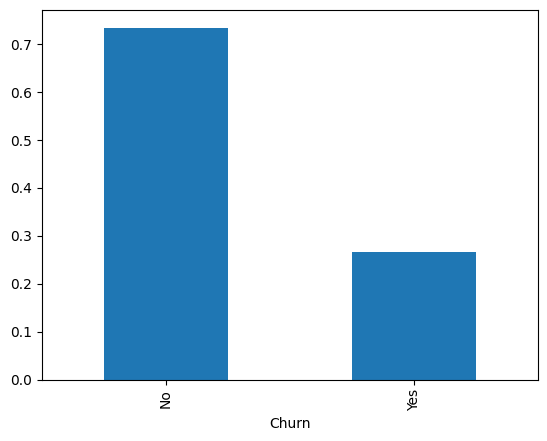

In [13]:
churn_df["Churn"].value_counts(normalize=True).plot(kind="bar")

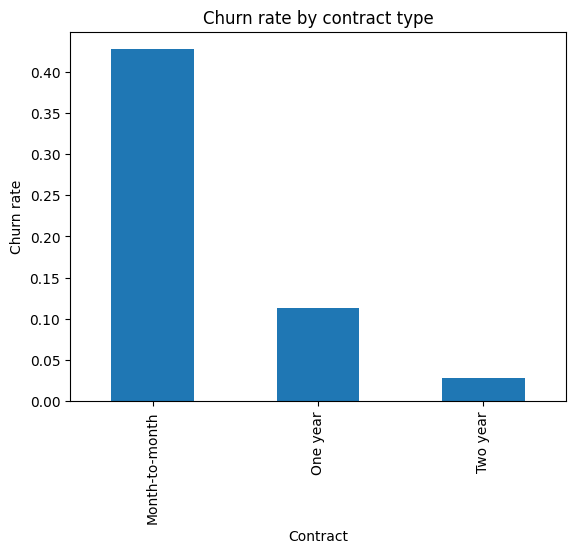

In [15]:
rates = pd.crosstab(
    churn_df["Contract"],
    churn_df["Churn"],
    normalize="index"
)["Yes"]

rates.plot(kind="bar")
plt.ylabel("Churn rate")
plt.title("Churn rate by contract type")
plt.show()

In [29]:
        # Defining target, and dividing features by type

churn_df["Churn"] = churn_df["Churn"].map({"No": 0, "Yes": 1})
target = 'Churn'

    ## Defining train-test split
X = churn_df.drop(target, axis=1)    # FEATURES
y = churn_df[target]                 # TARGET (Churn)

SEED = 619
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify= y, test_size =0.2, random_state =SEED)    # 80% TRAIN, 20% TEST

    ## Create num_features and cat_features for a ColumnTransformer for numeric and categorical features
num_features = X.select_dtypes(include='number').columns
cat_features = X.select_dtypes(exclude='number').columns
print(num_features, cat_features)


num_features = [
    'tenure', 'MonthlyCharges', 'TotalCharges',    # NUMERICAL
    'Charges_per_Month', 'Num_Services'
]

binary_features = [
    'SeniorCitizen', 'Partner', 'Dependents',    # BINARY
    'PhoneService', 'PaperlessBilling',
    'Is_New', 'Is_Loyal'
]

cat_features = [
    'gender', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',    # CATEGORICAL
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]

        # Creating ColumnTransformer preprocessor

preprocessor = ColumnTransformer([
    ("num_features", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),    # Impute with median and StandarScaler for NUMERICAL values
        ("scaler", StandardScaler())
    ]), num_features),

    ("binary_features", SimpleImputer(strategy="most_frequent"), binary_features),    # Impute binaries with the most frequent value

    ("cat_features", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),    # Impute categoricals with most frequent, and encode for models
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_features)
])

Index(['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService',
       'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'Charges_per_Month', 'Is_New', 'Is_Loyal', 'Num_Services'],
      dtype='object') Index(['customerID', 'gender', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod'],
      dtype='object')


In [30]:
        # Finding best params for XGBClassifier and RandomForest with RandomizedSearchCV (Logistic wont be tuned)

    ## XGBClassifier pipeline and best estimator

ratio = len(y_train[y_train==0]) / len(y_train[y_train==1])

xgb_pipe = ImbPipeline([
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=SEED, sampling_strategy=0.5)),
    ("xgbmodel", XGBClassifier(
        random_state=SEED,
        eval_metric="logloss",
        scale_pos_weight=ratio,
    ))
])

    ## XGBClassifier Grid

param_dist_xgb = {
    "xgbmodel__n_estimators": [200, 300, 400],
    "xgbmodel__max_depth": [3, 5, 8],
    "xgbmodel__learning_rate": [0.05, 0.1, 0.2],
    "xgbmodel__subsample": [0.8, 1.0],
    "xgbmodel__colsample_bytree": [0.8, 1.0]
}

    ## Instantiating RandomizedSearchCV to find the best hyperparameters

xgb_rsearch = RandomizedSearchCV(
    xgb_pipe,
    param_distributions=param_dist_xgb,
    n_iter=10,
    scoring="average_precision",    # Use average_precision because churn is imbalanced and probability-based, not a simple binary decision.
    cv=5,
    n_jobs=-1,
    random_state=SEED,
    verbose=2
)

xgb_rsearch.fit(X_train, y_train)

best_xgb = xgb_rsearch.best_estimator_
print(best_xgb)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['SeniorCitizen' 'Partner' 'Dependents' 'PhoneService' 'PaperlessBilling']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num_features',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges',
                                                   'Charges_per_Month',
                                                   'Num_Services']),
                                                 ('binary_features',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  ['SeniorCitizen', 'Partner',
                                

In [31]:
        # Finding best parameters for RandomForest

    ## Creating RF Pipeline with preprocessor and models


rf_pipe = ImbPipeline([
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=SEED, sampling_strategy=0.5)),
    ("rfmodel", RandomForestClassifier(random_state=SEED, class_weight='balanced', n_jobs=-1))
])

    ## RandomForest Grid

param_dist_rf = {
    'rfmodel__n_estimators': [200, 400, 600],
    'rfmodel__max_depth': [5, 10, 20, 30],
    'rfmodel__min_samples_split': [2, 5, 10],
    'rfmodel__min_samples_leaf': [1, 2, 4]
}

    ## Instantiating RandomizedSearchCV to find the best hyperparameters

rf_rsearch = RandomizedSearchCV(
    rf_pipe,
    param_distributions=param_dist_rf,
    n_iter=10,
    scoring='average_precision',    # Use average_precision because churn is imbalanced and probability-based, not a simple binary decision.
    cv=5,
    n_jobs=-1,
    random_state=SEED,
    verbose=2
)

rf_rsearch.fit(X_train, y_train)
best_rf = rf_rsearch.best_estimator_
print(best_rf)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['SeniorCitizen' 'Partner' 'Dependents' 'PhoneService' 'PaperlessBilling']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num_features',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges',
                                                   'Charges_per_Month',
                                                   'Num_Services']),
                                                 ('binary_features',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  ['SeniorCitizen', 'Partner',
                                

In [32]:
        # Creating lr pipelina and instantiating StackingClassifier

    ## Creating estimators and making a StackingCassifier

lr_pipe = ImbPipeline([
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=SEED, sampling_strategy=0.5)),
    ("model", LogisticRegression(max_iter=1000, class_weight='balanced'))
])

estimators = [
    ('rf', best_rf),
    ('xgb', best_xgb),
    ('lr', lr_pipe)
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    stack_method='predict_proba',
    cv=5,
    n_jobs=-1,
    verbose=2
)

stack.fit(X_train, y_train)

y_pred = stack.predict(X_test)
y_proba = stack.predict_proba(X_test)[:,1]

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['SeniorCitizen' 'Partner' 'Dependents' 'PhoneService' 'PaperlessBilling']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['SeniorCitizen' 'Partner' 'Dependents' 'PhoneService' 'PaperlessBilling']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['SeniorCitizen' 'Partner' 'Dependents' 'PhoneService' 'PaperlessBilling']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: User

ROC-AUC: 0.8737528740086284
              precision    recall  f1-score   support

           0       0.85      0.92      0.88      1035
           1       0.72      0.56      0.63       374

    accuracy                           0.82      1409
   macro avg       0.78      0.74      0.76      1409
weighted avg       0.82      0.82      0.82      1409



/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['SeniorCitizen' 'Partner' 'Dependents' 'PhoneService' 'PaperlessBilling']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['SeniorCitizen' 'Partner' 'Dependents' 'PhoneService' 'PaperlessBilling']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


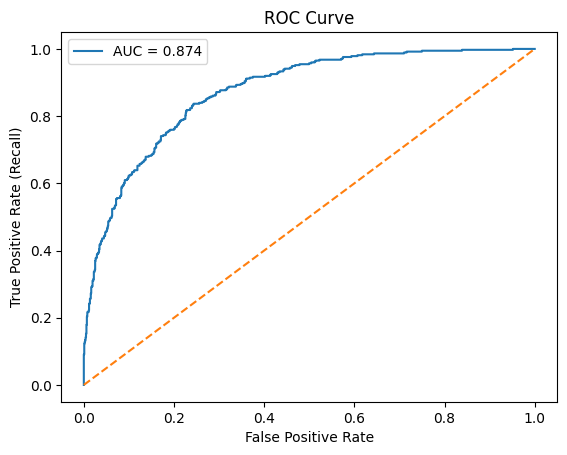

In [33]:
         # Making a visual representation of the ROC-AUC score

fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [34]:
        # Performing a cross-validation to assure no overfitting took place

models = {
    "lr": lr_pipe,
    "rf": rf_pipe,
    "xgb": xgb_pipe,
    "stack": stack
}

for name, model in models.items():
    score = cross_val_score(
        model,
        X, y,
        cv=5,
        scoring="average_precision",    # Use average_precision because churn is imbalanced and probability-based, not a simple binary decision.
        n_jobs=-1
    ).mean()

    print(name, '=', score)

lr = 0.6617324367719053
rf = 0.6022030577505026
xgb = 0.6180890256220755
stack = 0.6667060066321894


In [35]:
         # Finding the threshold with the highest recall

proba = stack.predict_proba(X_test)[:, 1]

for t in np.arange(0.1, 0.6, 0.05):
    preds = (proba >= t).astype(int)
    r = recall_score(y_test, preds)
    p = precision_score(y_test, preds)
    print(f"t={t:.2f}  recall={r:.3f}  precision={p:.3f}")

best_recall = {"t": 0.20, "r": 0.877, "p": 0.530}

print(f"prediction with the highest recall and precision >50%: t={best_recall['t']:.2f}  recall={best_recall['r']:.3f}  precision={best_recall['p']:.3f}")

t=0.10  recall=0.941  precision=0.428
t=0.15  recall=0.912  precision=0.478
t=0.20  recall=0.872  precision=0.517
t=0.25  recall=0.832  precision=0.553
t=0.30  recall=0.762  precision=0.579
t=0.35  recall=0.719  precision=0.616
t=0.40  recall=0.666  precision=0.643
t=0.45  recall=0.634  precision=0.681
t=0.50  recall=0.559  precision=0.716
t=0.55  recall=0.463  precision=0.762
prediction with the highest recall and precision >50%: t=0.20  recall=0.877  precision=0.530


/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['SeniorCitizen' 'Partner' 'Dependents' 'PhoneService' 'PaperlessBilling']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['SeniorCitizen' 'Partner' 'Dependents' 'PhoneService' 'PaperlessBilling']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['SeniorCitizen' 'Partner' 'Dependents' 'PhoneService' 'PaperlessBilling']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


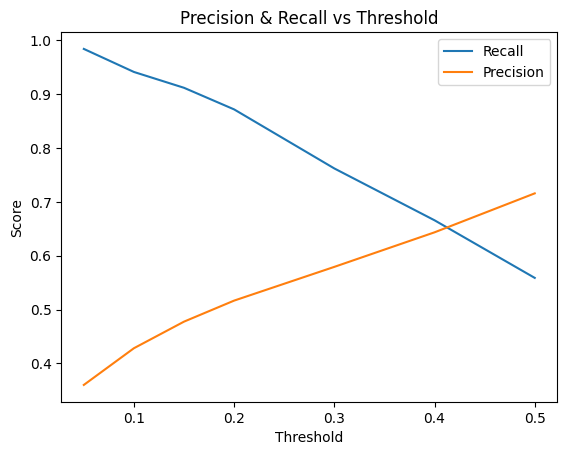

In [36]:
        # Visual representation of the highest recall (precision loss isn't as costly as recall loss... in churn)

precisions = []
recalls=[]
thresholds = [0.5, 0.4, 0.3, 0.2, 0.15, 0.1, 0.05]

for t in thresholds:
    preds = (y_proba >= t).astype(int)
    precisions.append(precision_score(y_test, preds))
    recalls.append(recall_score(y_test, preds))

plt.figure()
plt.plot(thresholds, recalls, label="Recall")
plt.plot(thresholds, precisions, label="Precision")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.title("Precision & Recall vs Threshold")
plt.show()

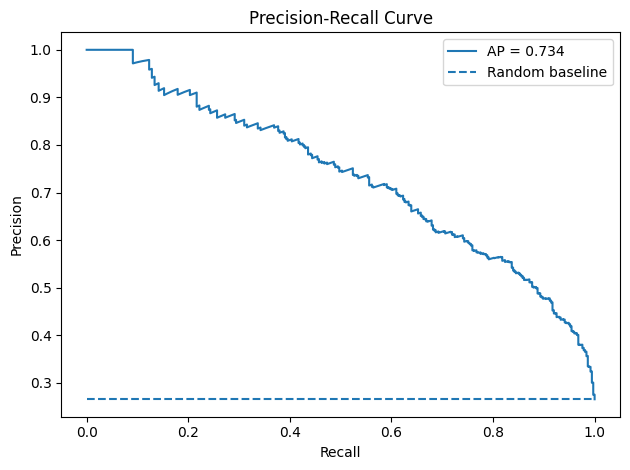

In [37]:
        # Visualizing a Precision-Recall Curve

precision, recall, _ = precision_recall_curve(y_test, proba)
ap = average_precision_score(y_test, proba)

plt.figure()
plt.plot(recall, precision, label=f"AP = {ap:.3f}")

baseline = y_test.mean()
plt.hlines(baseline, 0, 1, linestyles="--", label="Random baseline")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

           0       0.94      0.71      0.81      1035
           1       0.52      0.87      0.65       374

    accuracy                           0.75      1409
   macro avg       0.73      0.79      0.73      1409
weighted avg       0.83      0.75      0.76      1409

[[730 305]
 [ 48 326]]


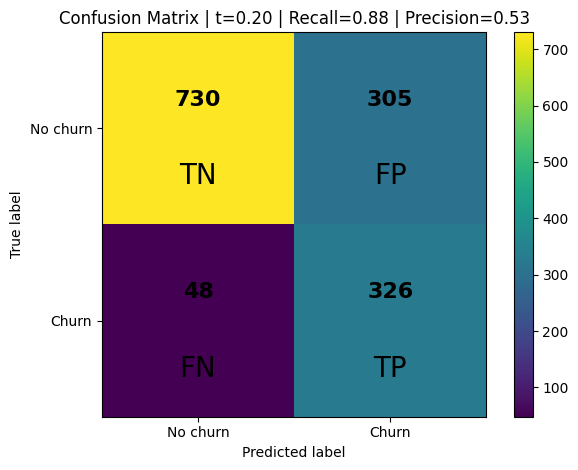

In [38]:
         #Visualizing confusion matrix

threshold = 0.20
preds = (proba >= threshold).astype(int)

cm = confusion_matrix(y_test, preds)

print(classification_report(y_test, preds))
print(cm)

disp = ConfusionMatrixDisplay(cm, display_labels=["No churn", "Churn"])
disp.plot(include_values=False)

labels = np.array([
    ["TN", "FP"],
    ["FN", "TP"]
])

for i in range(2):
    for j in range(2):
        plt.text(j, i-0.15, f"{cm[i, j]}",
                 ha="center", va="center",
                 fontsize=16, weight="bold")

        plt.text(j, i+0.25, labels[i, j],
                 ha="center", va="center",
                 fontsize=20)

r = recall_score(y_test, preds)
p = precision_score(y_test, preds)

plt.title(f"Confusion Matrix | t={best_recall['t']:.2f} | Recall={best_recall['r']:.2f} | Precision={best_recall['p']:.2f}")
plt.tight_layout()
plt.show()

In [39]:
         # Ranking the importance of the features

result = permutation_importance(
    stack, X_test, y_test,
    n_repeats=5,
    random_state=SEED,
    scoring="average_precision"    # Use average_precision because churn is imbalanced and probability-based, not a simple binary decision.
)                                  # It emphasizes correct ranking of high-risk customers and penalizes false positives.

# Transform to DataFrame

importance = pd.Series(result.importances_mean, index=X_test.columns)

print(importance.head(15).sort_values(ascending=False))

/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['SeniorCitizen' 'Partner' 'Dependents' 'PhoneService' 'PaperlessBilling']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['SeniorCitizen' 'Partner' 'Dependents' 'PhoneService' 'PaperlessBilling']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['SeniorCitizen' 'Partner' 'Dependents' 'PhoneService' 'PaperlessBilling']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: User

tenure              0.141495
InternetService     0.122584
OnlineSecurity      0.032144
TechSupport         0.018477
StreamingMovies     0.012740
StreamingTV         0.012730
MultipleLines       0.007321
OnlineBackup        0.005858
DeviceProtection    0.002598
gender              0.000921
PhoneService        0.000000
customerID          0.000000
Dependents          0.000000
Partner             0.000000
SeniorCitizen       0.000000
dtype: float64


/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['SeniorCitizen' 'Partner' 'Dependents' 'PhoneService' 'PaperlessBilling']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['SeniorCitizen' 'Partner' 'Dependents' 'PhoneService' 'PaperlessBilling']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['SeniorCitizen' 'Partner' 'Dependents' 'PhoneService' 'PaperlessBilling']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['SeniorCitizen' 'Partner' 'Dependents' 'PhoneService' 'PaperlessBilling']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['SeniorCitizen' 'Partner' 'Dependents' 'PhoneService' 'PaperlessBilling']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: User

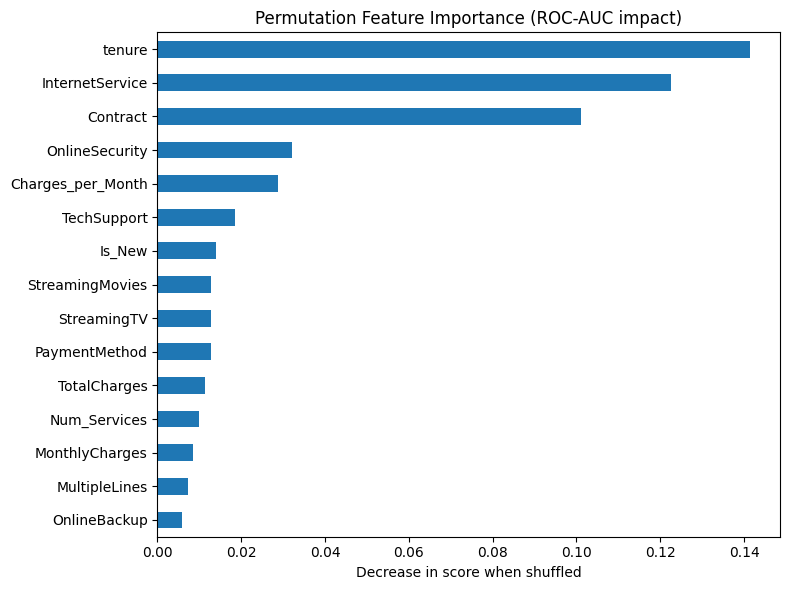

In [40]:
        # Visualizing feature importance

result = permutation_importance(
    stack, X_test, y_test,
    n_repeats=5,
    random_state=SEED,
    scoring="average_precision"    # Use average_precision because churn is imbalanced and probability-based, not a simple binary decision.
)

# convertir a dataframe
importance = pd.Series(result.importances_mean, index=X_test.columns).sort_values(ascending=False)

# graficar top 15
top_n = 15
plt.figure(figsize=(8,6))
importance.head(top_n).sort_values().plot(kind="barh")

plt.title("Permutation Feature Importance (ROC-AUC impact)")
plt.xlabel("Decrease in score when shuffled")
plt.tight_layout()
plt.show()